In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
# تحميل ملف البيانات (MNIST digits dataset)
!gdown --id 18pMSdWcKVFl8vjaHFIfOxYM-igo00CLp
df = pd.read_csv('digit_rf (1).csv')

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=18pMSdWcKVFl8vjaHFIfOxYM-igo00CLp
To: /content/digit_rf (1).csv
100% 76.8M/76.8M [00:01<00:00, 59.8MB/s]


In [ ]:
y = df['label']
X = df.drop('label', axis=1)

# حساب وزن كل رقم
class_counts = y.value_counts().sort_index()
print(class_counts)
#normalization for x values only
X = X / 255.0
print("Pixel range after normalization:")
print("Min:", X.min().min(), "Max:", X.max().max())

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64
Pixel range after normalization:
Min: 0.0 Max: 1.0


In [ ]:
#التأكد من عمود الأرقام لن يتأثر بال normalization
print(y.head(10))

0    1
1    0
2    1
3    4
4    0
5    0
6    7
7    3
8    5
9    3
Name: label, dtype: int64


In [ ]:
df.head()


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# step2: discover data
df.shape

(42000, 785)

In [ ]:
#step3: cleaning dataset
#missing value
df.isnull().sum()


,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,0
pixel780,0
pixel781,0
pixel782,0


In [ ]:
print("أقل قيمة في البيانات:", df.min().min())
print("أعلى قيمة في البيانات:", df.max().max())

أقل قيمة في البيانات: 0
أعلى قيمة في البيانات: 255


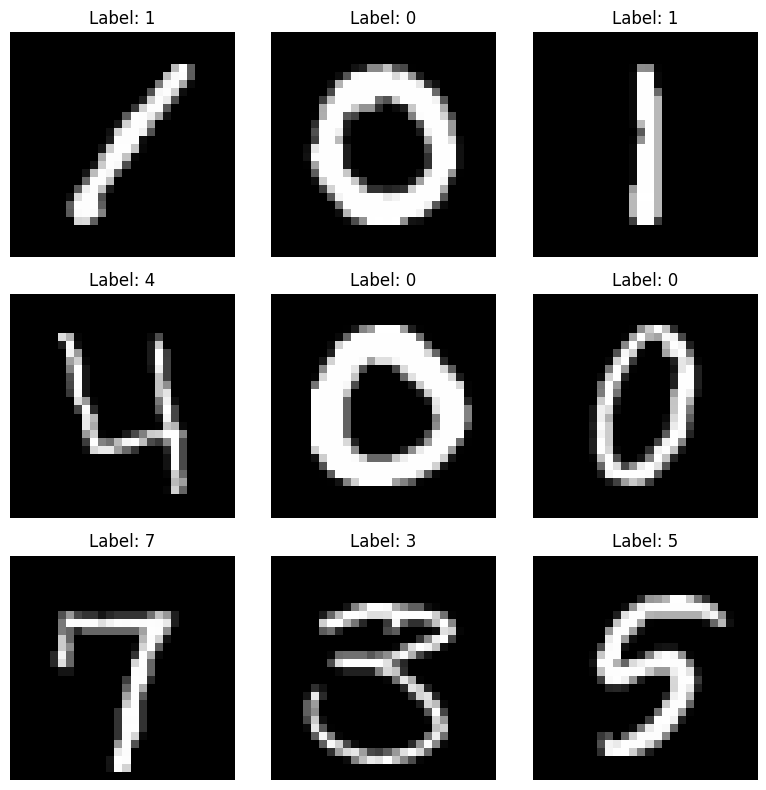

In [ ]:
# عرض 9 صور عشوائية
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)

    image = X.iloc[i].values.reshape(28,28)

    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {y.iloc[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# التحقق إذا يوجد قيم أقل من 0 أو أكبر من 255
outliers = df[(df < 0) | (df > 255)].count().sum()

print("عدد القيم الشاذة خارج النطاق:", outliers)

عدد القيم الشاذة خارج النطاق: 0


In [ ]:
# فصل المخرجات (الرقم الصحيح)
y = df['label']

# المدخلات (البكسلات)
X = df.drop('label', axis=1)

print(X.shape)
print(y.shape)

(42000, 784)
(42000,)


In [ ]:

from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

In [ ]:
print("Training size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Testing size:", X_test.shape)

Training size: (29400, 784)
Validation size: (6300, 784)
Testing size: (6300, 784)


In [ ]:
#scaling
X = X / 255.0
print("Minimum value after scaling:", X.min().min())
print("Maximum value after scaling:", X.max().max())

Minimum value after scaling: 0.0
Maximum value after scaling: 1.0


In [ ]:
#تدريب النموذج الأول
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
log_model = LogisticRegression(max_iter=1000)

In [ ]:
log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred_log = log_model.predict(X_test)

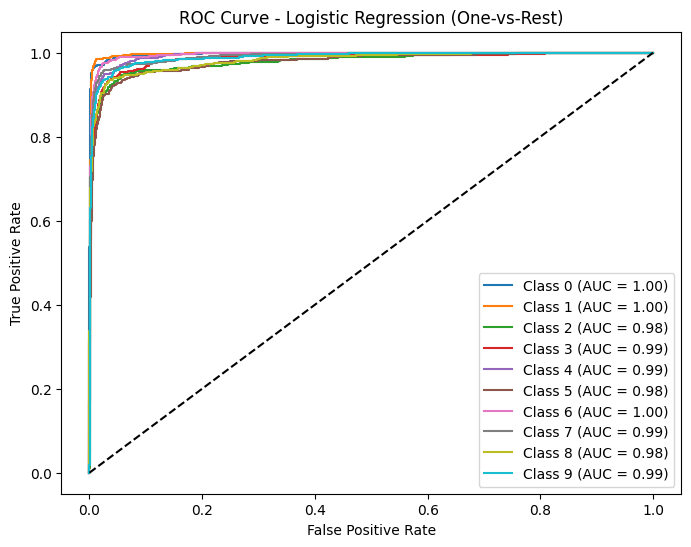

In [ ]:
# --------------------------------------------------
# Step 10: رسم ROC Curve (One-vs-Rest)
# --------------------------------------------------

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# تحويل y_test إلى One-Hot Encoding
y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4,5,6,7,8,9])
n_classes = y_test_bin.shape[1]

# الحصول على احتمالات التنبؤ
y_proba = log_model.predict_proba(X_test)

# رسم منحنى ROC لكل رقم
plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

# خط التخمين العشوائي
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (One-vs-Rest)")
plt.legend(loc="lower right")
plt.show()

In [ ]:
# التنبؤ على بيانات الاختبار
y_pred_log = log_model.predict(X_test)

# عرض أول 10 تنبؤات
print("First 10 Predictions:", y_pred_log[:10])

# عرض القيم الحقيقية للمقارنة
print("First 10 True Labels:", y_test.iloc[:10].values)

First 10 Predictions: [7 9 9 5 3 0 8 9 5 5]
First 10 True Labels: [7 3 9 6 3 0 8 9 5 5]


Baseline Model Accuracy (Logistic Regression): 0.8985714285714286

Confusion Matrix:
 [[570   0   1   0   1   9  10   0   3   2]
 [  0 671   7   5   0   4   1   1   8   2]
 [  9  10 558  20  12  11   7  10   8   5]
 [  1   0  26 590   3  27   4   7  15   7]
 [  2   4   5   2 521   1   7   5   6  16]
 [  6   0   9  22  10 485  12   2  24   5]
 [  3   2  13   2   9  15 583   1   3   0]
 [  1   2  12   7  11   1   1 631   6  23]
 [  3  12  11  24   6  14   8   1 507   5]
 [  1   0   3   7  18  12   1  22   5 545]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96       596
           1       0.96      0.96      0.96       699
           2       0.87      0.86      0.86       650
           3       0.87      0.87      0.87       680
           4       0.88      0.92      0.90       569
           5       0.84      0.84      0.84       575
           6       0.92      0.92      0.92       631
           7       0.93  

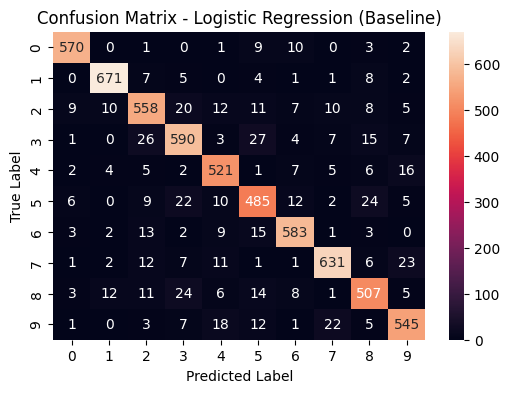

In [ ]:
# التنبؤ باستخدام بيانات الاختبار
y_pred_log = log_model.predict(X_test)

# --------------------------------------------------
# التقييم
# --------------------------------------------------

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# حساب الدقة
print("Baseline Model Accuracy (Logistic Regression):", accuracy_score(y_test, y_pred_log))

# طباعة Confusion Matrix كنص
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

# طباعة تقرير التصنيف الكامل
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

# --------------------------------------------------
# رسم Confusion Matrix بشكل مرئي
# --------------------------------------------------

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm_log, annot=True, fmt='d')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression (Baseline)")
plt.show()

In [1]:
from google.colab import files
files.download("digit_rf (1).csv")

FileNotFoundError: Cannot find file: digit_rf (1).csv